# Lab 9 - task solutions

In [72]:
#pip install ucimlrepo

In [73]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 

df_heart = pd.concat([X, y], axis=1)

In [74]:
df_heart.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


**Task 1.1 and 1.2**

Changing data types.

In [75]:
df_heart.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object

In [76]:
#print(heart_disease.metadata)
print(heart_disease.variables)

        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical         NaN   
3   trestbps  Feature      Integer         NaN   
4       chol  Feature      Integer         NaN   
5        fbs  Feature  Categorical         NaN   
6    restecg  Feature  Categorical         NaN   
7    thalach  Feature      Integer         NaN   
8      exang  Feature  Categorical         NaN   
9    oldpeak  Feature      Integer         NaN   
10     slope  Feature  Categorical         NaN   
11        ca  Feature      Integer         NaN   
12      thal  Feature  Categorical         NaN   
13       num   Target      Integer         NaN   

                                          description  units missing_values  
0                                                 NaN  years             no  
1                                                 NaN    NaN             no  
2              

In [77]:
categorical_features = heart_disease.variables[heart_disease.variables['type'] == 'Categorical']['name'].values.tolist()

In [78]:
categorical_features

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

In [79]:
df_heart.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [80]:
# new dataframe without missing values
df_heart_no_na = df_heart.dropna()

In [81]:
# single column
# df_heart['sex'] = df_heart['sex'].astype('category')

# loop
for feature_name in categorical_features:
    df_heart[feature_name] = df_heart[feature_name].astype('category')

In [82]:
df_heart.dtypes

age            int64
sex         category
cp          category
trestbps       int64
chol           int64
fbs         category
restecg     category
thalach        int64
exang       category
oldpeak      float64
slope       category
ca           float64
thal        category
num            int64
dtype: object

**Task 2**

In [83]:
# unique values
df_heart['num'].unique()

array([0, 2, 1, 3, 4])

In [84]:
df_heart['num'].value_counts()

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

**Task 2.1**

<Axes: >

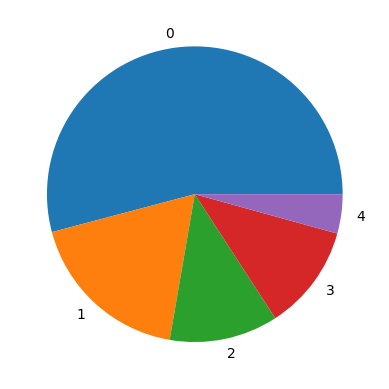

In [85]:
df_heart['num'].value_counts().plot(kind='pie')

In [86]:
corr_matrix = df_heart.corr()
corr_matrix         

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
age,1.000000,-0.097542,0.104139,0.284946,0.208950,0.118530,0.148868,-0.393806,0.091661,0.203805,0.161770,0.362605,0.127389,0.222853
sex,-0.097542,1.000000,0.010084,-0.064456,-0.199915,0.047862,0.021647,-0.048663,0.146201,0.102173,0.037533,0.093185,0.380936,0.224469
cp,0.104139,0.010084,1.000000,-0.036077,0.072319,-0.039975,0.067505,-0.334422,0.384060,0.202277,0.152050,0.233214,0.265246,0.407075
trestbps,0.284946,-0.064456,-0.036077,1.000000,0.130120,0.175340,0.146560,-0.045351,0.064762,0.189171,0.117382,0.098773,0.133554,0.157754
chol,0.208950,-0.199915,0.072319,0.130120,1.000000,0.009841,0.171043,-0.003432,0.061310,0.046564,-0.004062,0.119000,0.014214,0.070909
fbs,0.118530,0.047862,-0.039975,0.175340,0.009841,1.000000,0.069564,-0.007854,0.025665,0.005747,0.059894,0.145478,0.071358,0.059186
restecg,0.148868,0.021647,0.067505,0.146560,0.171043,0.069564,1.000000,-0.083389,0.084867,0.114133,0.133946,0.128343,0.024531,0.183696
thalach,-0.393806,-0.048663,-0.334422,-0.045351,-0.003432,-0.007854,-0.083389,1.000000,-0.378103,-0.343085,-0.385601,-0.264246,-0.279631,-0.415040
exang,0.091661,0.146201,0.384060,0.064762,0.061310,0.025665,0.084867,-0.378103,1.000000,0.288223,0.257748,0.145570,0.329680,0.397057
oldpeak,0.203805,0.102173,0.202277,0.189171,0.046564,0.005747,0.114133,-0.343085,0.288223,1.000000,0.577537,0.295832,0.341004,0.504092
